In [ ]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
import sys
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# Configuracion para importar src
current_working_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_working_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_20 = feda.obtener_datos_madrid(conexion, 2020, 2020, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_20)

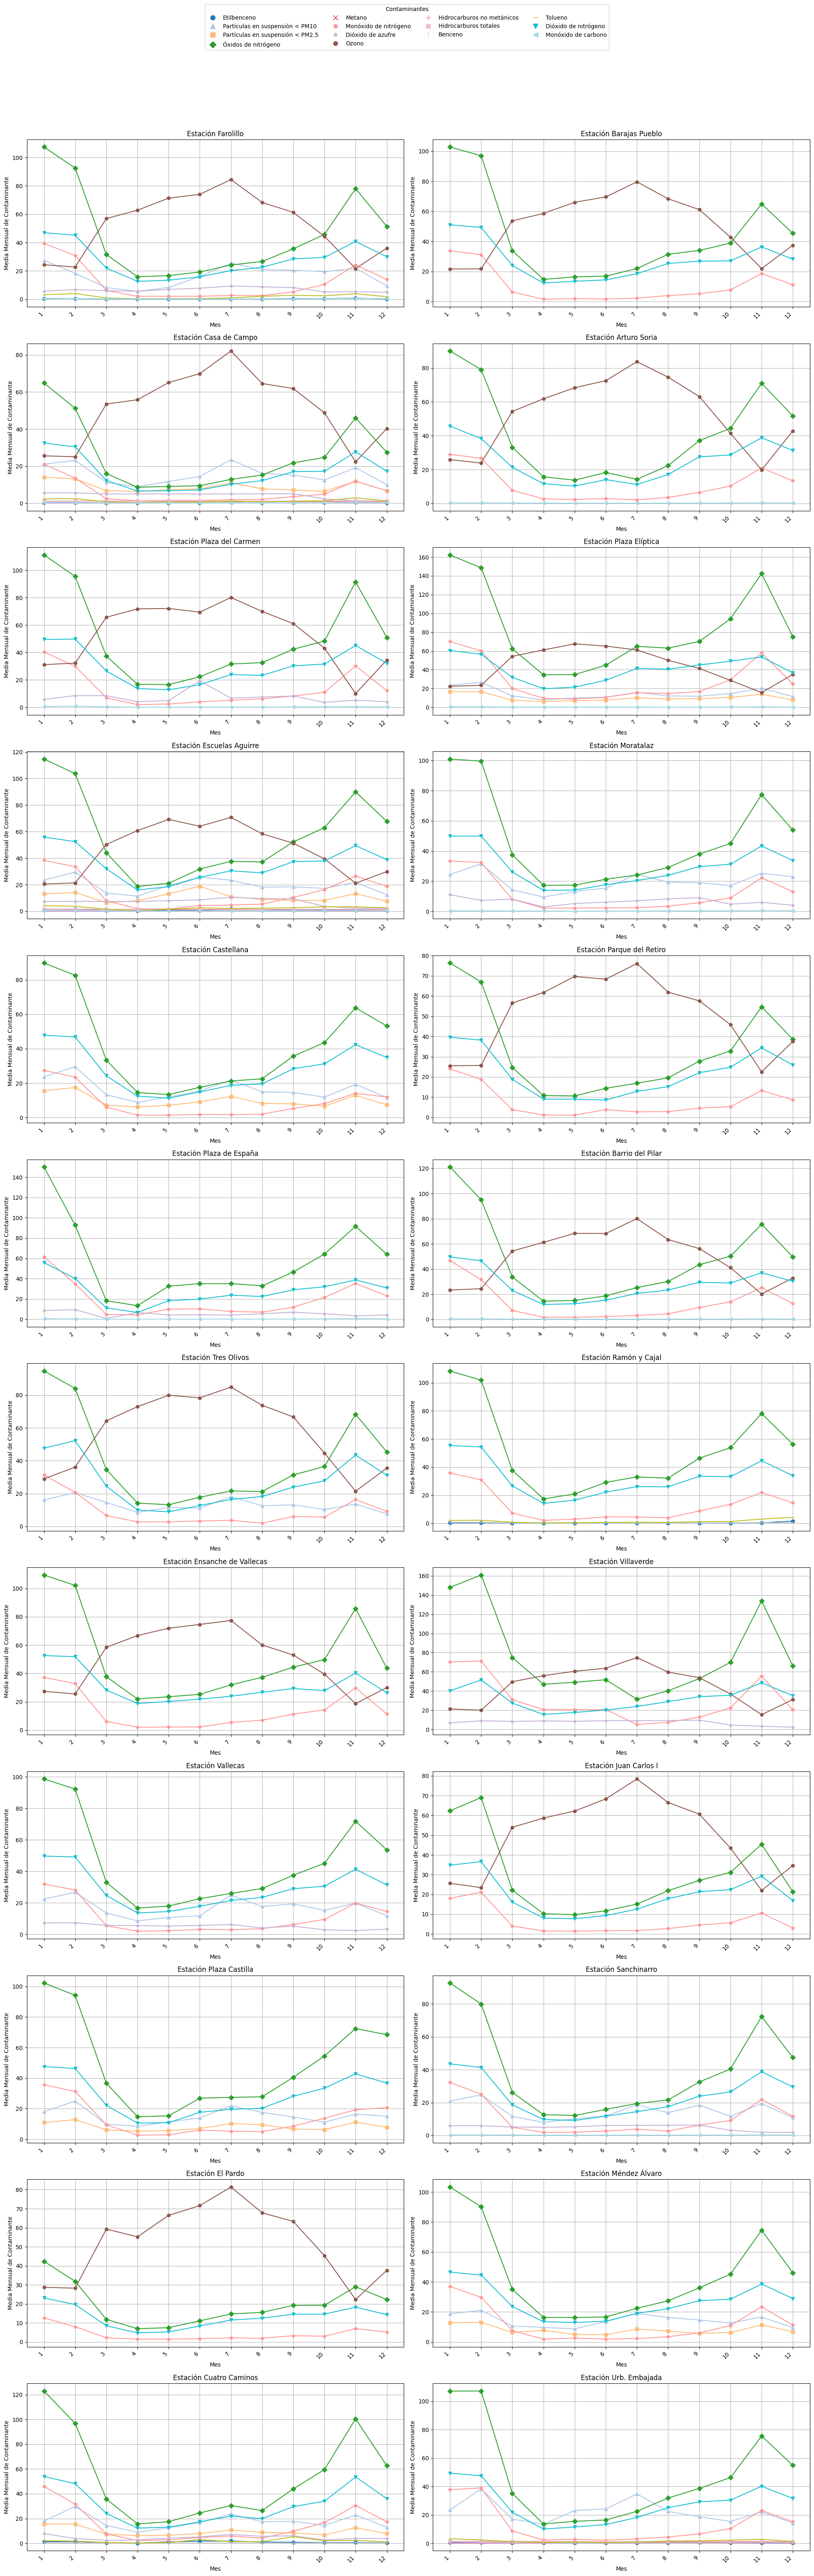

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

Analizamos los contaminantes que se miden en más estaciones, ya que son los que permiten mejor comparación entre ellas.

In [5]:
contaminantes_por_estacion = (
    madrid_20.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Óxidos de nitrógeno""",24
"""Monóxido de nitrógeno""",24
"""Dióxido de nitrógeno""",24
"""Ozono""",14
"""Partículas en suspensión < PM1…",13
"""Monóxido de carbono""",10
"""Dióxido de azufre""",10
"""Partículas en suspensión < PM2…",7
"""Benceno""",6


Los contaminantes más medidos (Óxidos de nitrógeno, Dióxido de nitrógeno, Monóxido de nitrógeno y Ozono)  mantienen el patrón de años anteriores en todas las estaciones, aunque se podría señalar que, en algunas estaciones el valor de los compuestos de nitrógeno parece ser constante en abril y mayo o incluso con un ligero descenso, posiblemente consecuencia del confinamiento y, a final de año tienen el pico em noviembre para volver a bajar en diciembre. En cambio el ozono presenta su mayor pico en julio para casi todas las estaciones en las que se mide.  

El siguiente que aparece en más estaciones es **Partículas en suspensión < PM10** que en este año presenta picos en febrero, julio y noviembre.   
El **monóxido de carbono** se mide en 10 estaciones aunque parece tener un valor muy cercano a 0 en todas las estaciones todo el año.  
El **dióxido de azufre** también se mide en 10 estaciones y aunque se mantiene relativamente en niveles bajos, este año hay un pico en junio en la estación de Plaza del Carmen.